# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download EV Adoption Behavior Dataset](https://www.kaggle.com/datasets/roshaank20/ev-adoption-behaviour)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('EV_Adoption_and_Range_Anxiety_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


## last Five row

In [4]:
df.tail()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


## Shape of our dataset

In [5]:
df.shape

(10000, 15)

## List out all columns

In [6]:
df.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Buyer_ID                        object
Age                              int64
Gender                          object
Annual_Income_USD              float64
City_Type                       object
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Current_Car_Type                object
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Home_Charging_Possible          object
Environmental_Concern_Level    float64
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

## Check Null Value

In [9]:
df.isnull().sum()

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64

## Handle missing values

In [10]:
df['Annual_Income_USD'] = df['Annual_Income_USD'].fillna(df['Annual_Income_USD'].median())

df['Daily_Commute_km'] = df['Daily_Commute_km'].fillna(df['Daily_Commute_km'].median())

df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].fillna(
    df['Environmental_Concern_Level'].median()
)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,46.936200,85366.551200,41.089030,1.859900,5.346900,7.458200,2.983100
std,12.945968,32545.198864,23.139275,0.855421,4.049074,5.259374,1.400718
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61883.500000,23.600000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,106938.500000,56.700000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

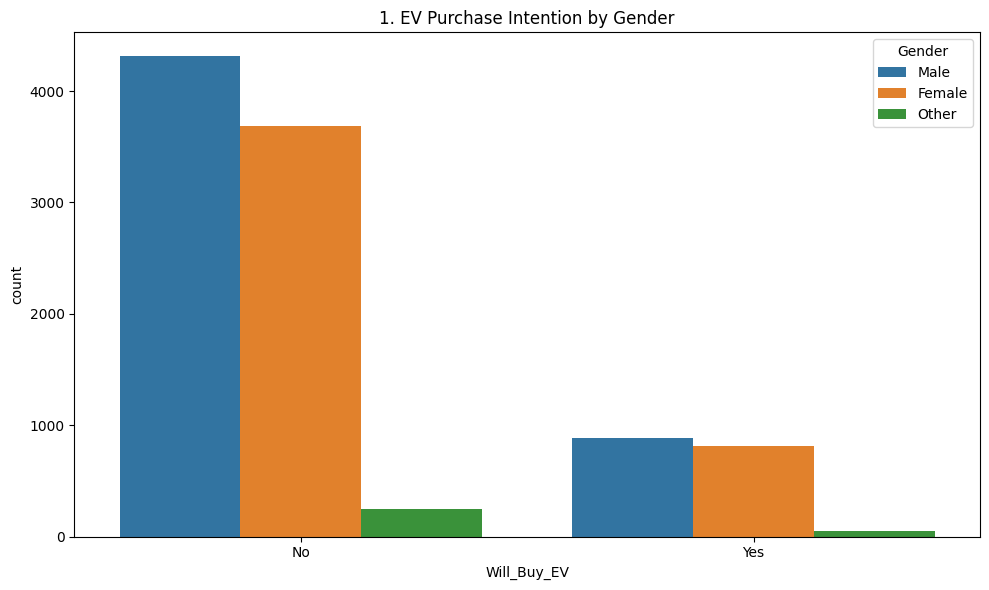

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Will_Buy_EV', hue='Gender')
plt.title(f'{plot_no}. EV Purchase Intention by Gender')
show_fig()
plot_no += 1

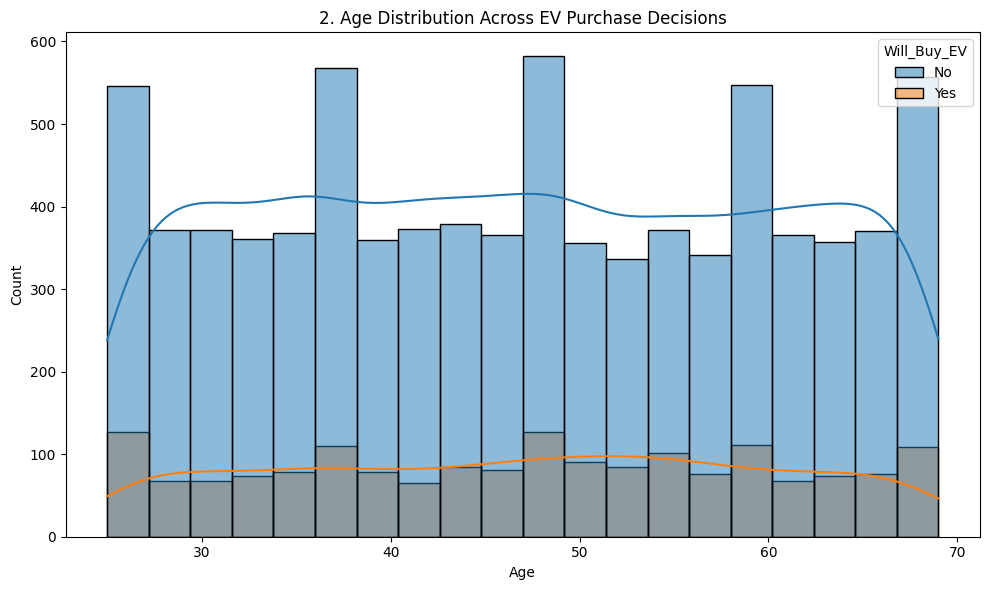

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Will_Buy_EV', kde=True, bins=20)
plt.title(f'{plot_no}. Age Distribution Across EV Purchase Decisions')
show_fig()
plot_no += 1

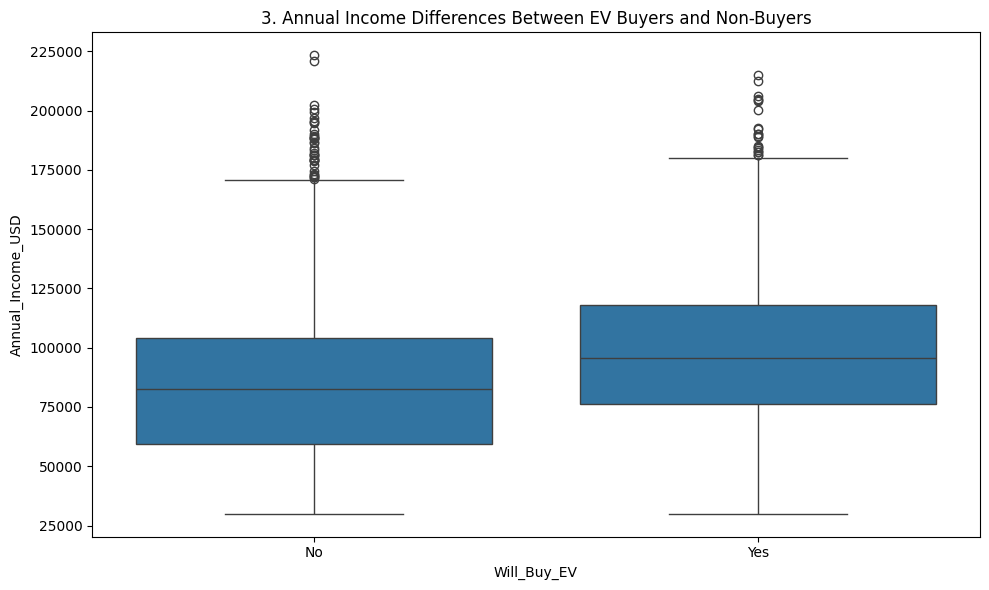

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Annual_Income_USD')
plt.title(f'{plot_no}. Annual Income Differences Between EV Buyers and Non-Buyers')
show_fig()
plot_no += 1

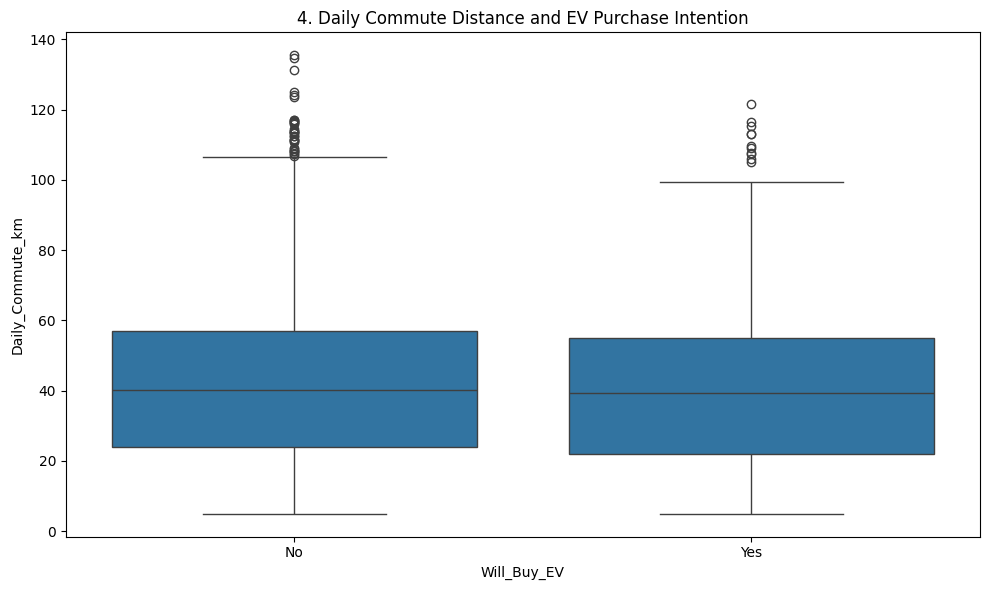

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Daily_Commute_km')
plt.title(f'{plot_no}. Daily Commute Distance and EV Purchase Intention')
show_fig()
plot_no += 1

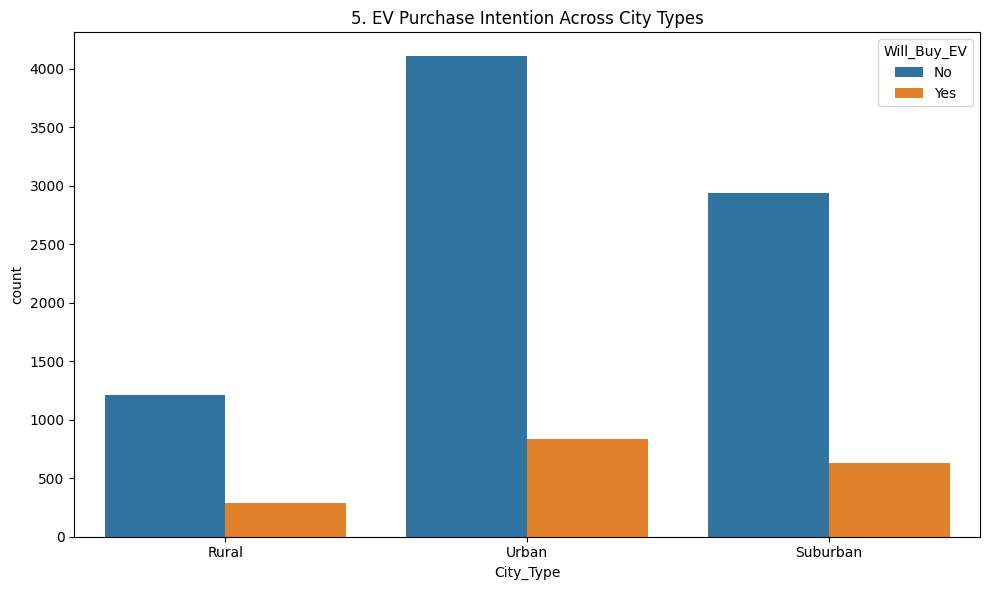

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='City_Type', hue='Will_Buy_EV')
plt.title(f'{plot_no}. EV Purchase Intention Across City Types')
show_fig()
plot_no += 1

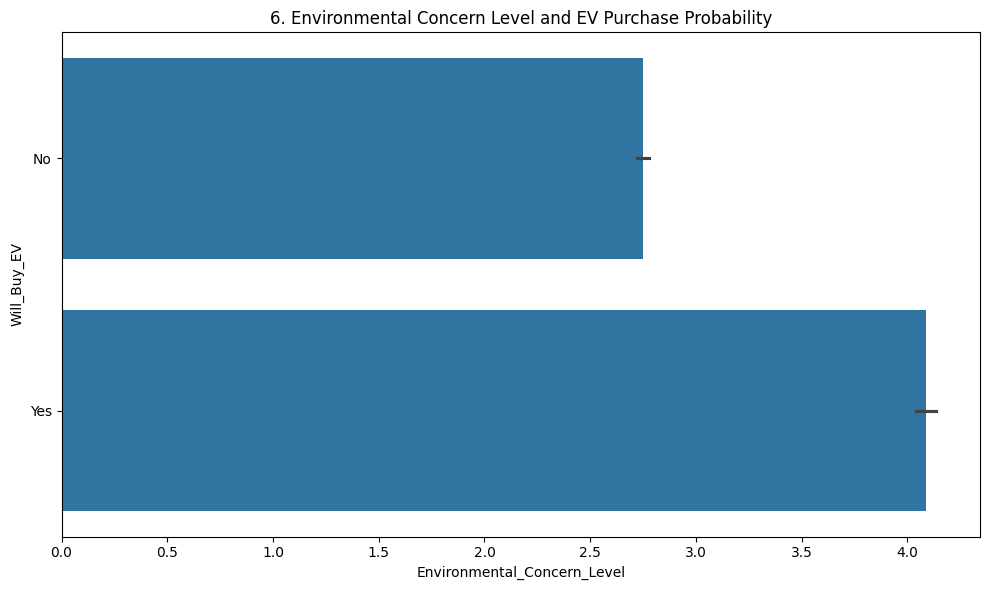

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Environmental_Concern_Level', y='Will_Buy_EV')
plt.title(f'{plot_no}. Environmental Concern Level and EV Purchase Probability')
show_fig()
plot_no += 1

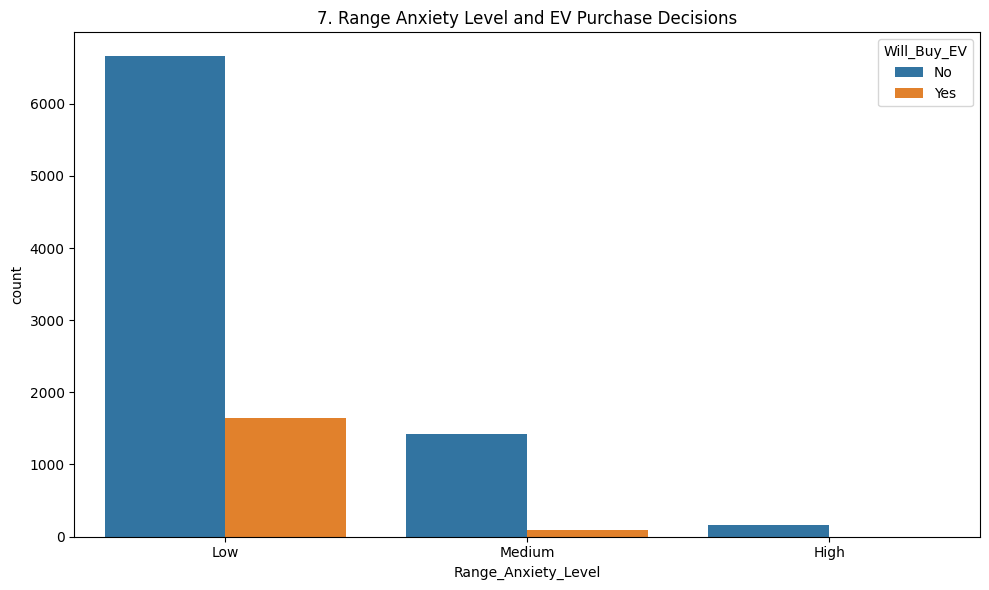

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Range_Anxiety_Level', hue='Will_Buy_EV', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Range Anxiety Level and EV Purchase Decisions')
show_fig()
plot_no += 1

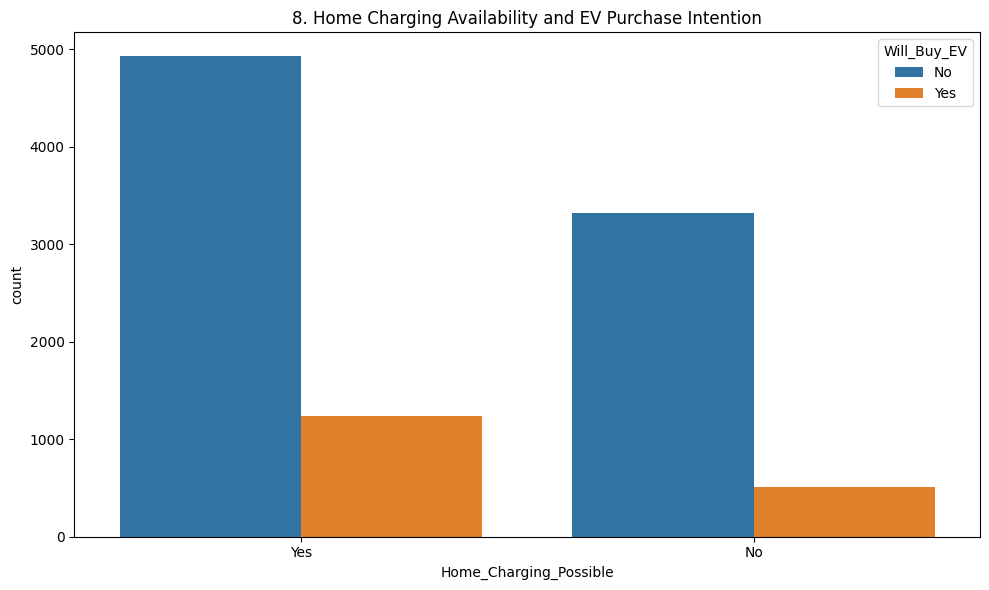

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Home_Charging_Possible', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Home Charging Availability and EV Purchase Intention')
show_fig()
plot_no += 1

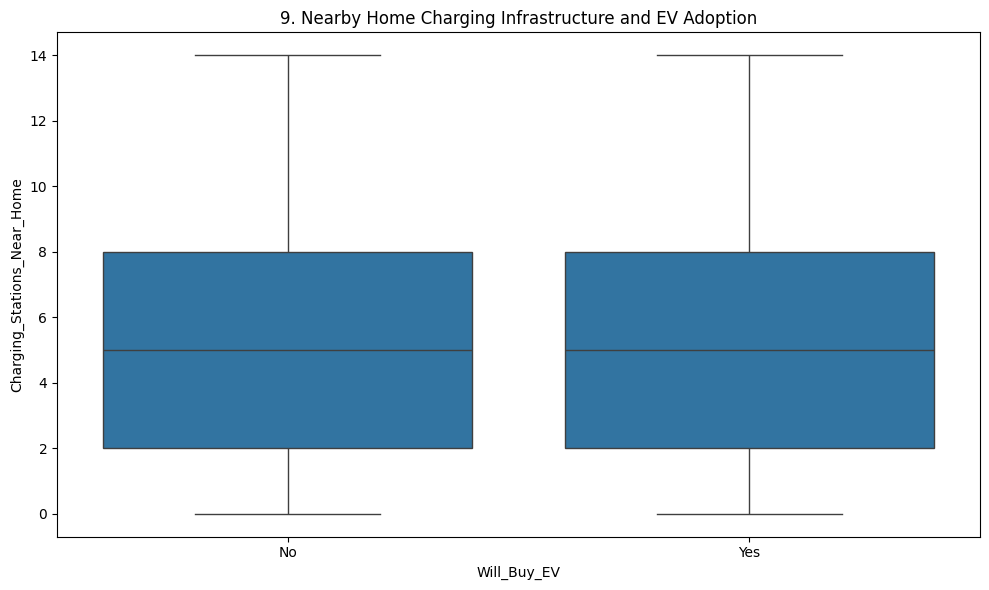

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Home')
plt.title(f'{plot_no}. Nearby Home Charging Infrastructure and EV Adoption')
show_fig()
plot_no += 1

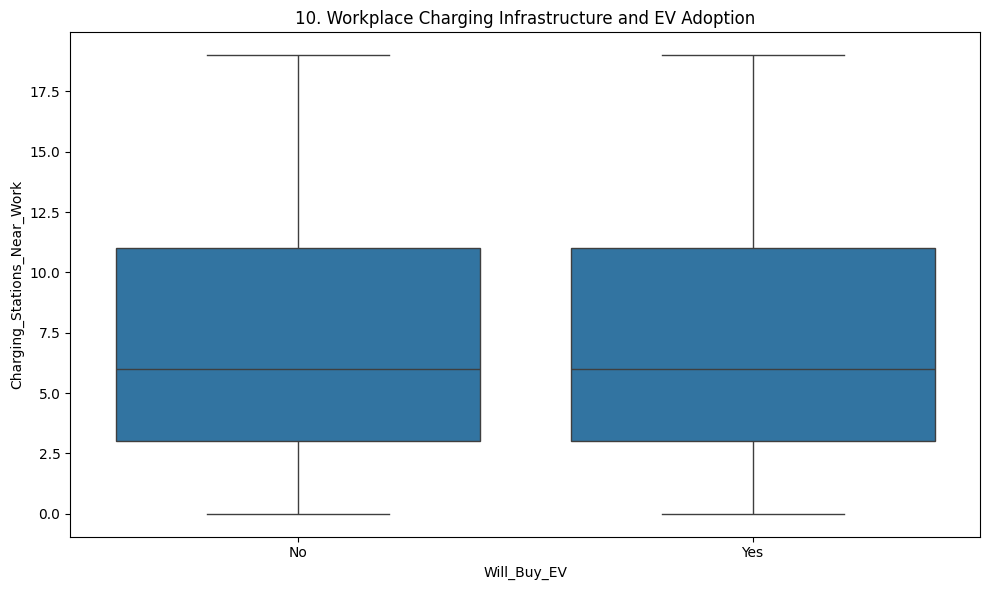

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Work')
plt.title(f'{plot_no}. Workplace Charging Infrastructure and EV Adoption')
show_fig()
plot_no += 1

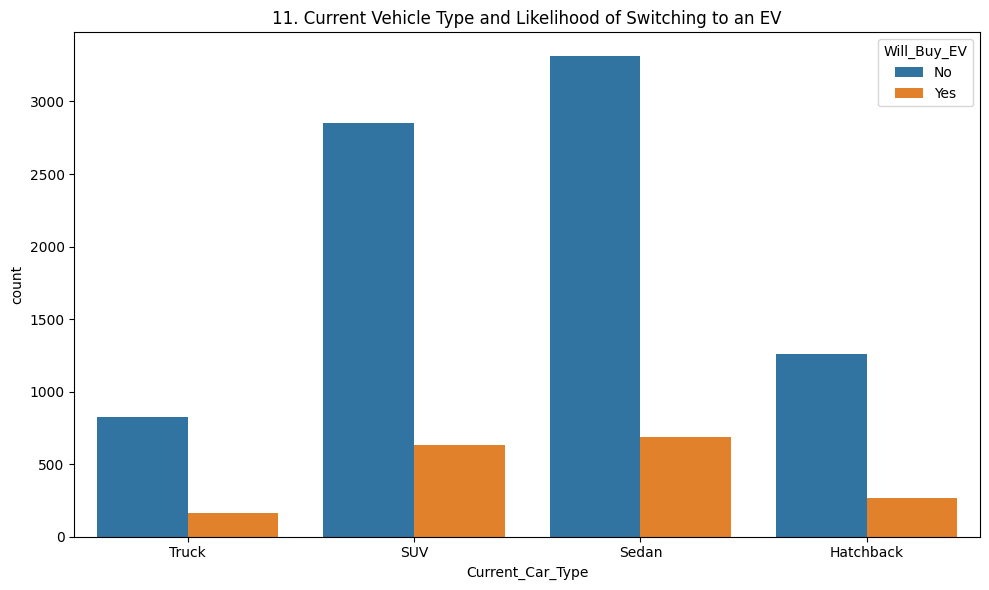

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Current_Car_Type', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Current Vehicle Type and Likelihood of Switching to an EV')
show_fig()
plot_no += 1

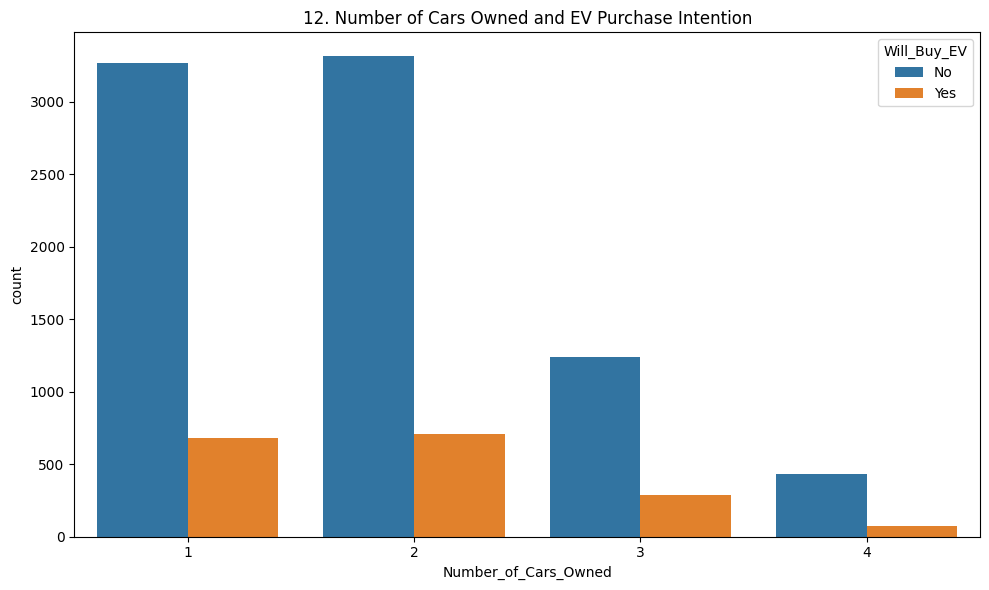

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Number_of_Cars_Owned', hue='Will_Buy_EV')
plt.title(f'{plot_no}. Number of Cars Owned and EV Purchase Intention')
show_fig()
plot_no += 1

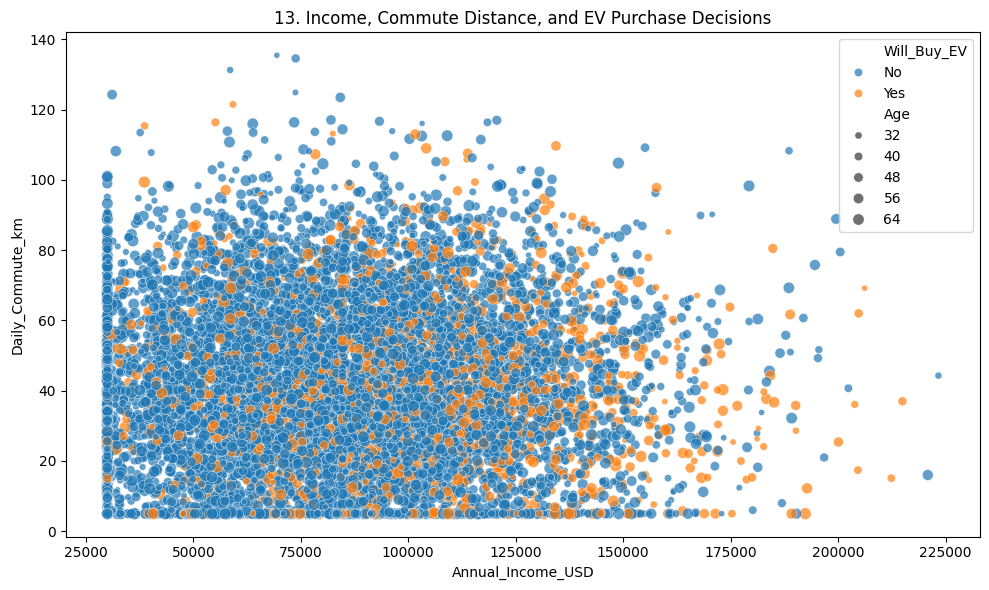

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual_Income_USD', y='Daily_Commute_km', hue='Will_Buy_EV', size='Age', alpha=0.7)
plt.title(f'{plot_no}. Income, Commute Distance, and EV Purchase Decisions')
show_fig()
plot_no += 1

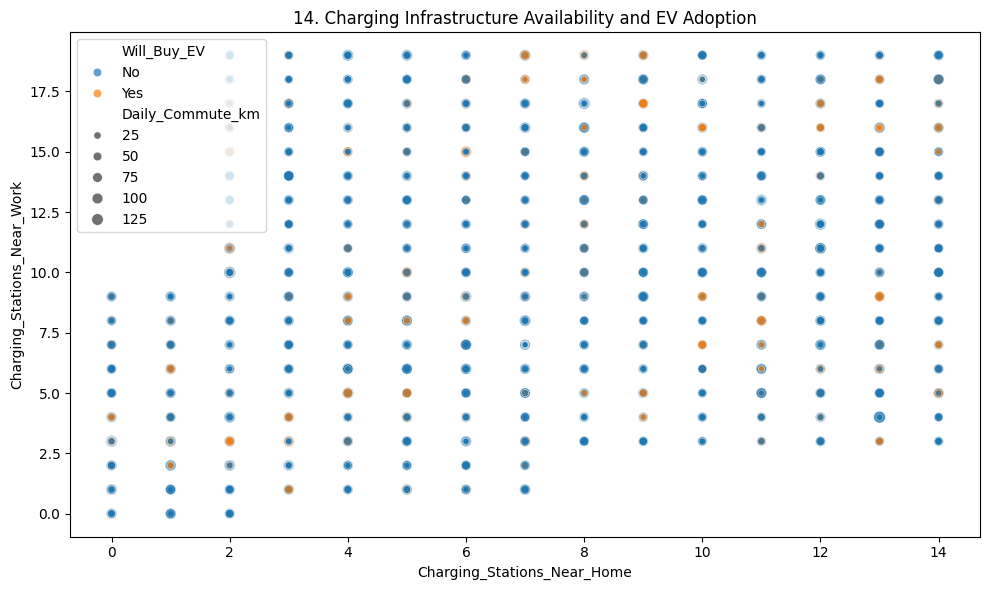

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Charging_Stations_Near_Home', y='Charging_Stations_Near_Work', hue='Will_Buy_EV', size='Daily_Commute_km', alpha=0.7)
plt.title(f'{plot_no}. Charging Infrastructure Availability and EV Adoption')
show_fig()
plot_no += 1

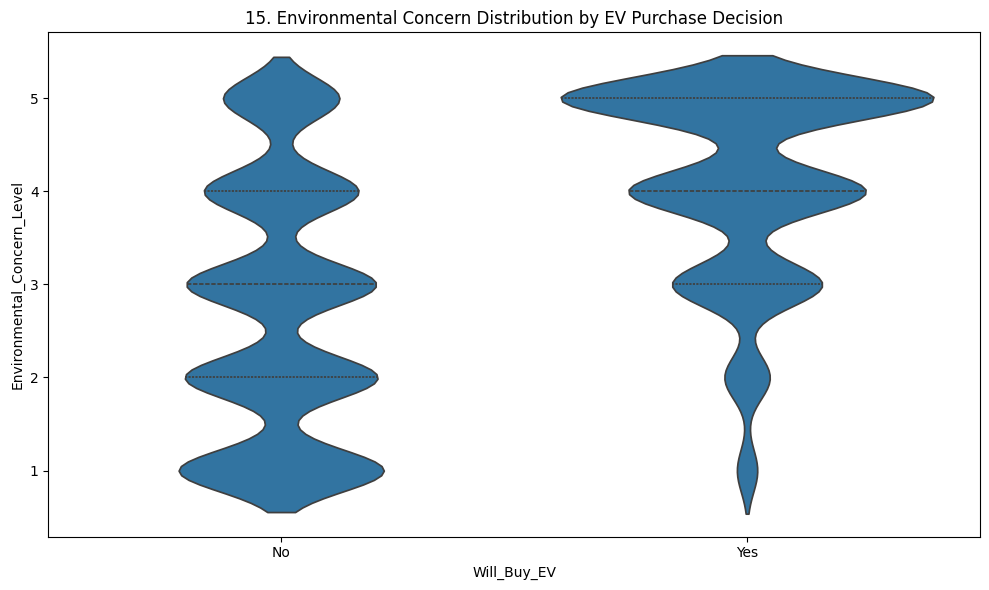

In [28]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Will_Buy_EV', y='Environmental_Concern_Level', inner='quartile')
plt.title(f'{plot_no}. Environmental Concern Distribution by EV Purchase Decision')
show_fig()
plot_no += 1

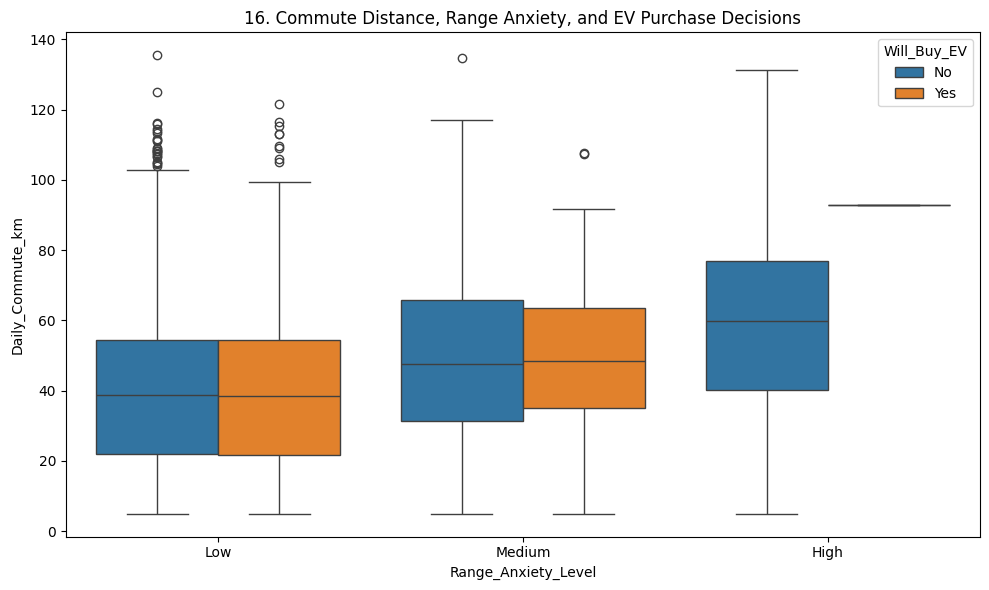

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Range_Anxiety_Level', y='Daily_Commute_km', hue='Will_Buy_EV', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Commute Distance, Range Anxiety, and EV Purchase Decisions')
show_fig()
plot_no += 1

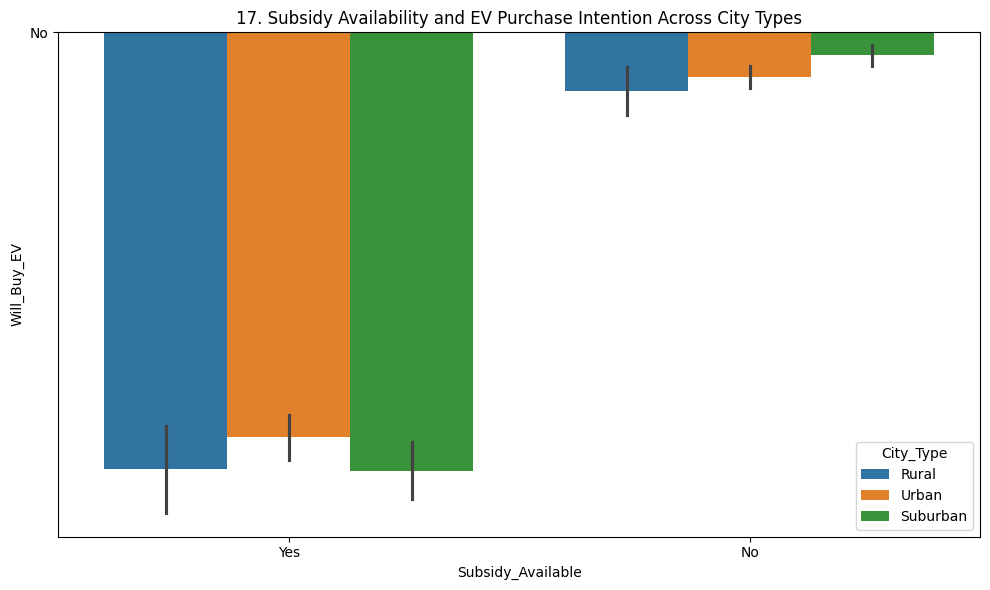

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Subsidy_Available', y='Will_Buy_EV', hue='City_Type')
plt.title(f'{plot_no}. Subsidy Availability and EV Purchase Intention Across City Types')
show_fig()
plot_no += 1

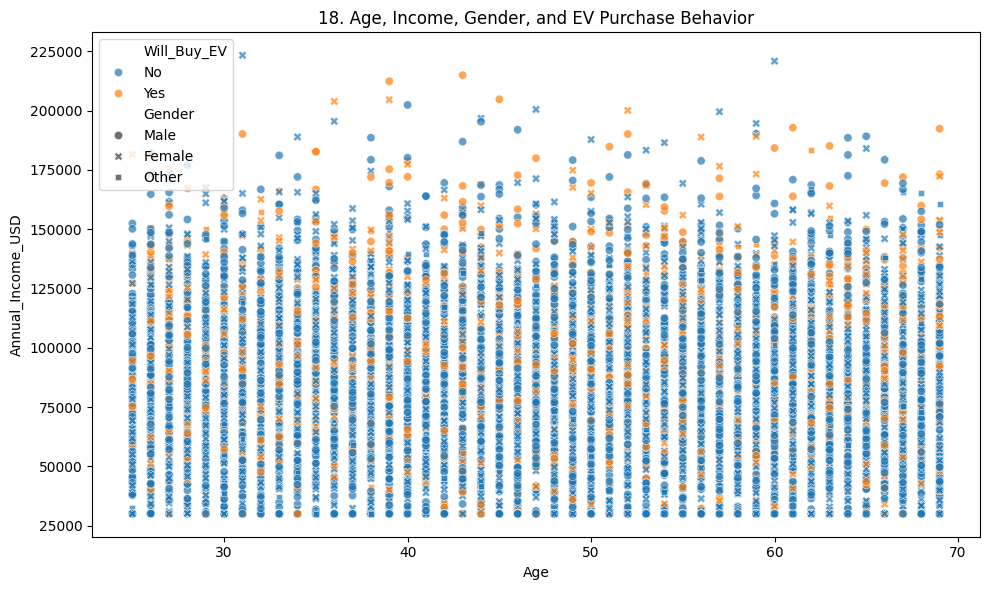

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Annual_Income_USD', hue='Will_Buy_EV', style='Gender', alpha=0.7)
plt.title(f'{plot_no}. Age, Income, Gender, and EV Purchase Behavior')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

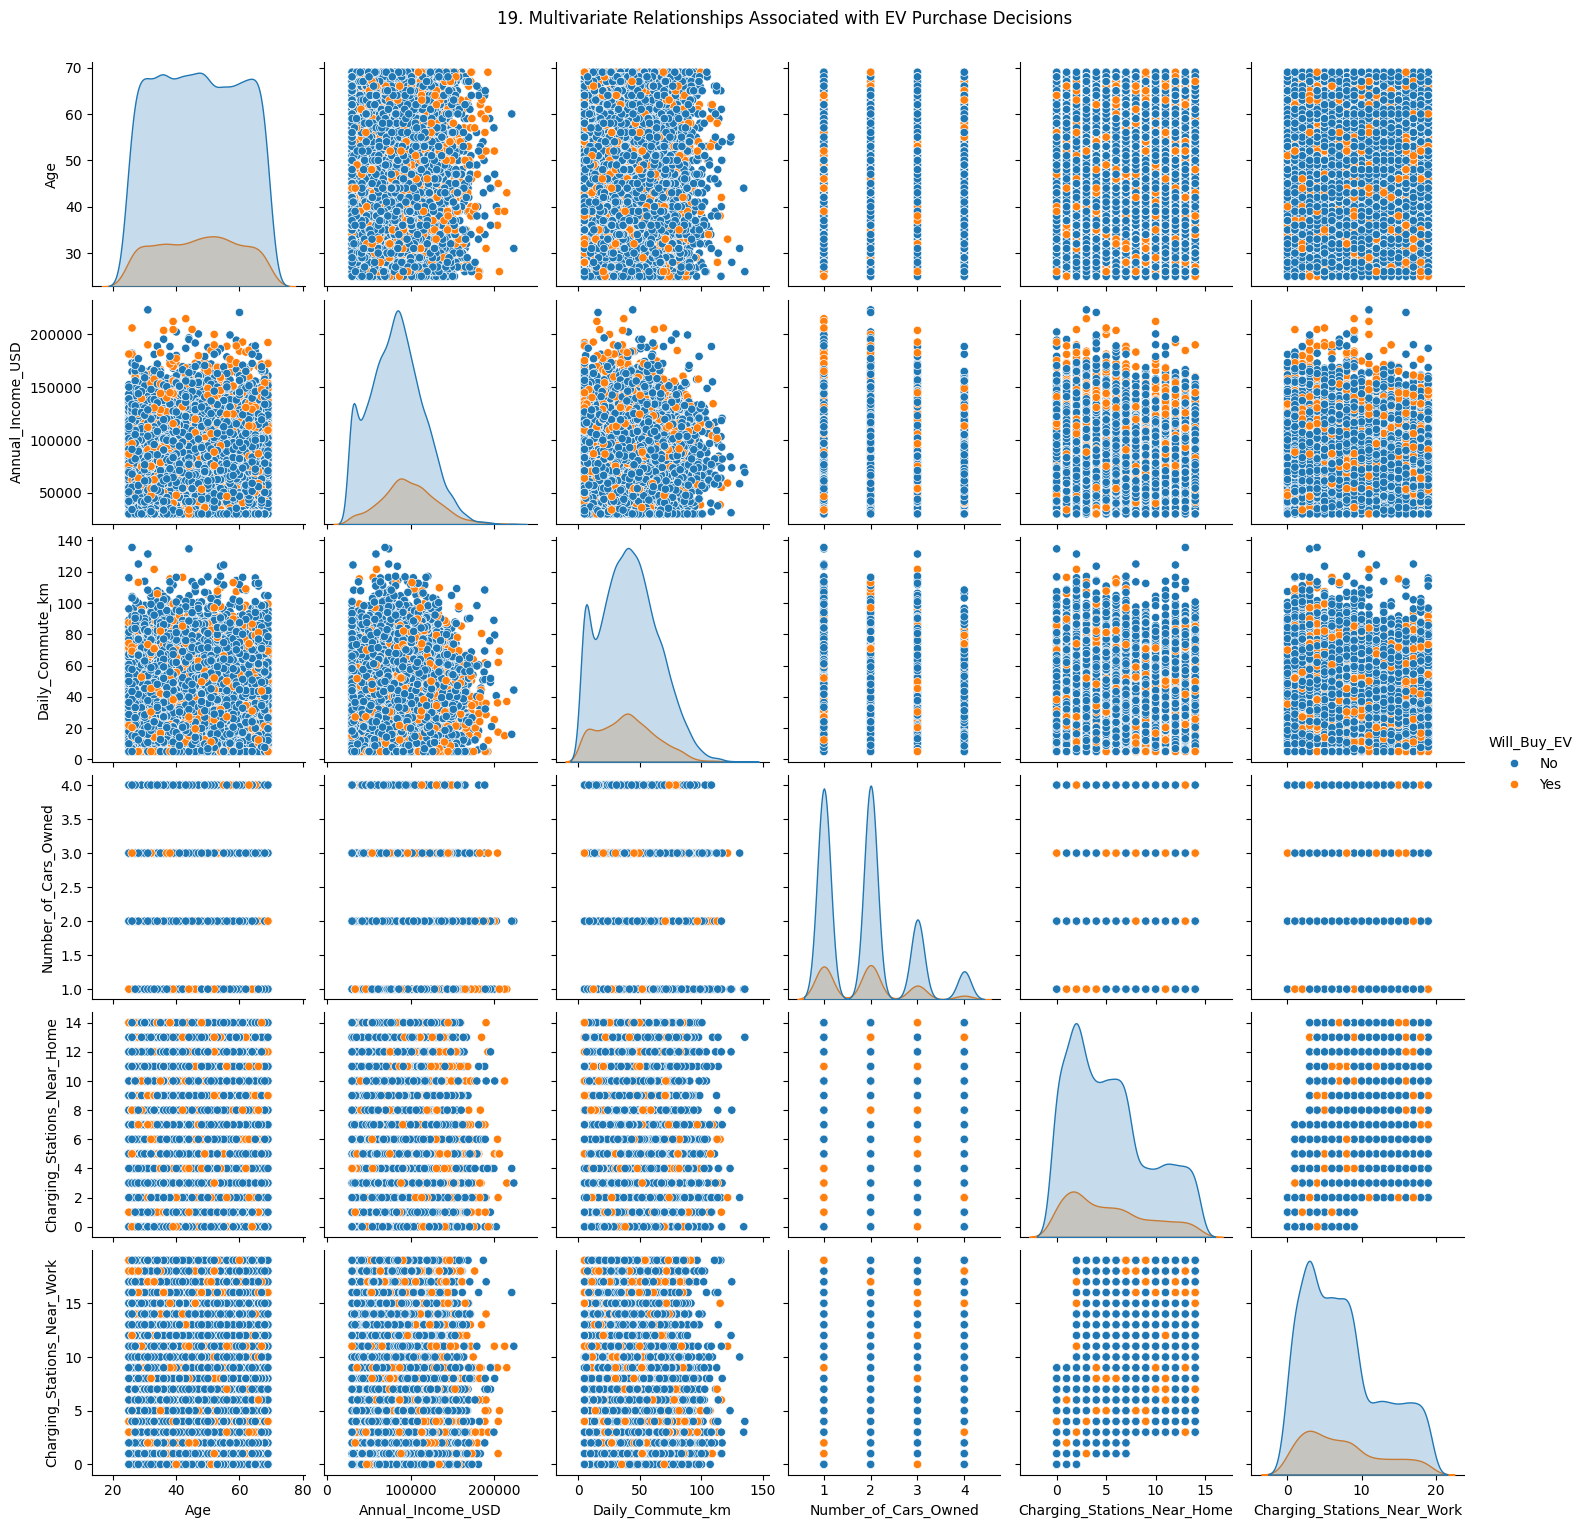

In [32]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Will_Buy_EV']], hue='Will_Buy_EV')
plt.suptitle(f'{plot_no}. Multivariate Relationships Associated with EV Purchase Decisions', y=1.02)
plt.show()
plot_no += 1

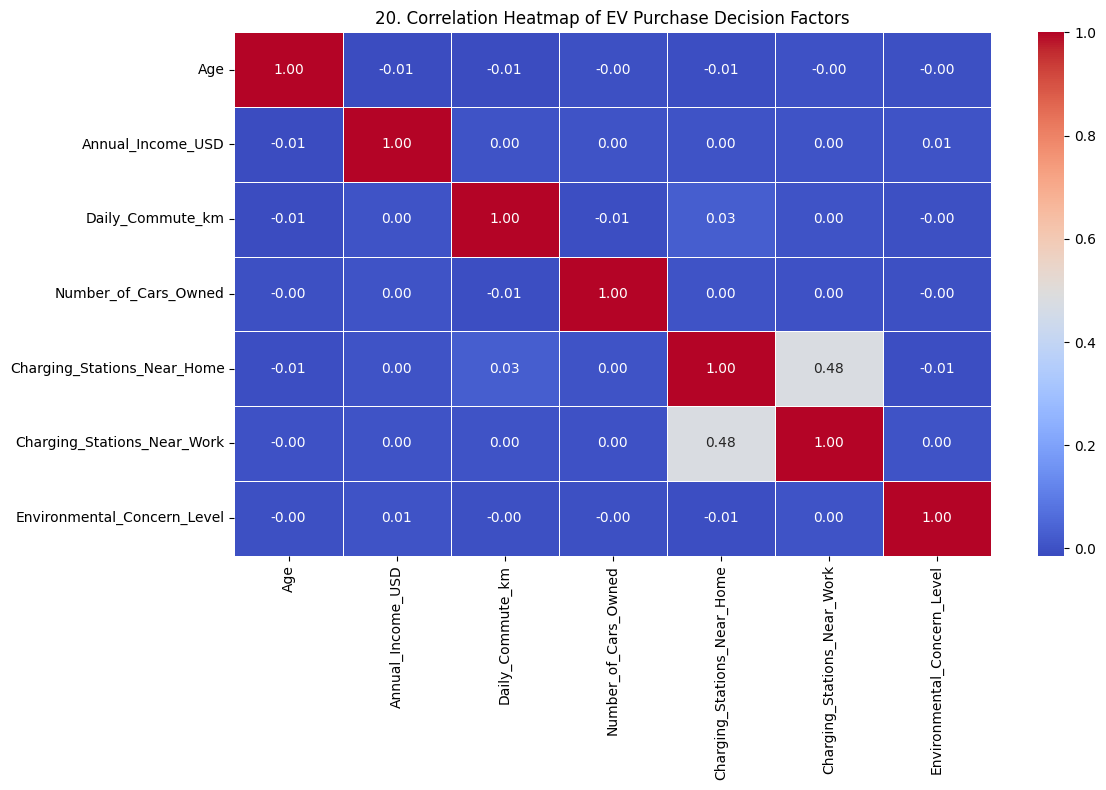

In [33]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of EV Purchase Decision Factors')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [34]:
X = df.drop(columns=['Buyer_ID', 'Will_Buy_EV'])
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

## Identify numerical and categorical columns

In [35]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

## Preprocess numerical and categorical features

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

## Create the classification model

In [37]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=42
    ))
])

## Split data into training and testing sets

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train the model

In [39]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [40]:
y_pred = model.predict(X_test)

## Calculate and print accuracy

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8685


## Plot confusion matrix

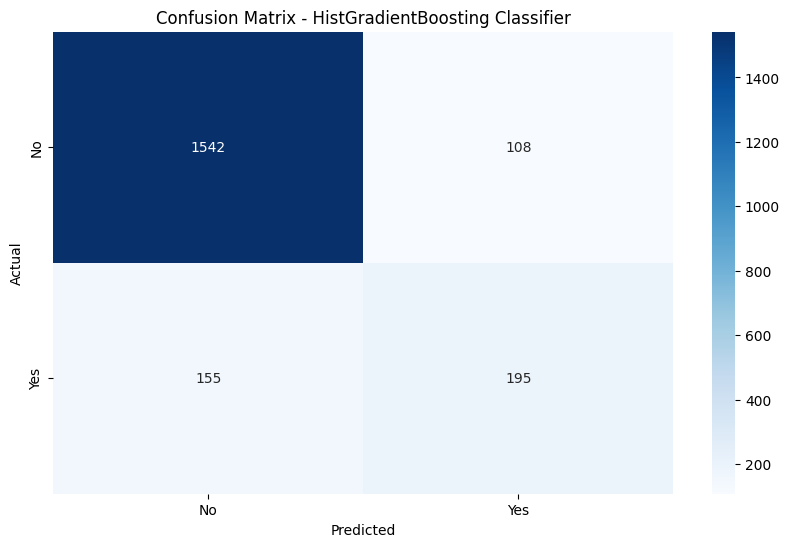

In [42]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(10,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - HistGradientBoosting Classifier')
plt.show()